In [2]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
insurance_data = pd.read_csv("insurance.csv")

X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for alpha=0.001:  20922599.871035974
MSE for alpha=0.1:  20921803.69843139
MSE for alpha=1:  20914832.635089148
MSE for alpha=2:  20908106.779954527
MSE for alpha=5:  20890881.000633504
MSE for alpha=10:  20872844.794796687
MSE for alpha=20:  20877828.53237883
MSE for alpha=30:  20937537.13393977
MSE for alpha=40:  21046489.293890774
MSE for alpha=50:  21196929.869608898
MSE for alpha=100:  22423172.68602322


<Axes: >

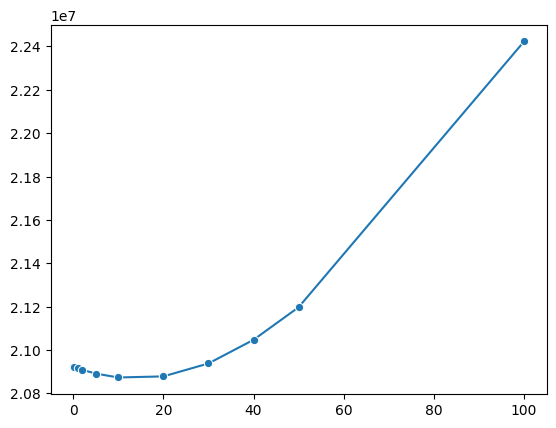

In [ ]:
import seaborn as sns

alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)  
    print(f"MSE for alpha={a}: ", mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker="o")

In [7]:
from sklearn.linear_model import LassoCV
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)

print("best alpha: ", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse = ", mse)
print("s2 = ", r2)
print(y_pred)


best alpha:  0.001
mse =  20922599.871035974
s2 =  0.8652317499151698
[11244.90059978  7419.09546268 33108.56314007 10825.70490225
 28165.85343431  6492.31635767  2795.32365354 14417.83354245
  5686.99898738 11674.71818244 20657.63411334  9146.42228702
  5695.47634768 51922.22671926 52110.29374917 46640.13982805
 11685.29658629 43258.62998667 10134.76616091 27544.19263391
  5590.70961111  9112.26802402  1829.44144206  4568.32135944
 12451.66467979 12838.43441863 13233.1683341   6449.57391511
 11799.9295961   1825.10892897  9707.98336691 12978.53929819
  3236.118998    7025.38251479  4125.34903234 10091.32515432
  3262.60158493  9119.59900771 26284.76520845 37686.42549368
  4634.26679081  3702.06925208 12658.70586842 12849.09340889
  6810.6449285  12752.77601579  4474.36939417  5198.07859716
 41615.56500411  6338.52575124 14310.54334662  2272.59365192
  9166.72907954  2711.78458203 11905.93655599 12175.66877205
  5854.00924076 36417.51200106 12666.41162659 12587.07781541
 13954.80847283

In [8]:
print(y_test)

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64


In [9]:
insurance_data = pd.read_csv("insurance.csv")

X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)
y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse = ", mse)
print("s2 = ", r2)
print(y_pred)


mse =  20922599.871035974
s2 =  0.8652317499151698
[11244.90059978  7419.09546268 33108.56314007 10825.70490225
 28165.85343431  6492.31635767  2795.32365354 14417.83354245
  5686.99898738 11674.71818244 20657.63411334  9146.42228702
  5695.47634768 51922.22671926 52110.29374917 46640.13982805
 11685.29658629 43258.62998667 10134.76616091 27544.19263391
  5590.70961111  9112.26802402  1829.44144206  4568.32135944
 12451.66467979 12838.43441863 13233.1683341   6449.57391511
 11799.9295961   1825.10892897  9707.98336691 12978.53929819
  3236.118998    7025.38251479  4125.34903234 10091.32515432
  3262.60158493  9119.59900771 26284.76520845 37686.42549368
  4634.26679081  3702.06925208 12658.70586842 12849.09340889
  6810.6449285  12752.77601579  4474.36939417  5198.07859716
 41615.56500411  6338.52575124 14310.54334662  2272.59365192
  9166.72907954  2711.78458203 11905.93655599 12175.66877205
  5854.00924076 36417.51200106 12666.41162659 12587.07781541
 13954.80847283  6697.60648305 143